# COMIND Subtyping Demo (refactored fitter)
This notebook generates synthetic longitudinal data and fits the refactored `SubtypingEM` (`fit` helpers, `assignments.py`, `model_selection.py`, staged `theta_solver_stages` instead of `jac_toggle`).


In [7]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import random
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import confusion_matrix, adjusted_rand_score

from COMIND_transformer.model_generator import generate_logistic_model, get_adjacency_matrix, create_patient_list
from COMIND_transformer.synthetic_data_generator import generate_synthetic_data
from COMIND_transformer.visualization import * 
from COMIND_transformer.utils import *
from COMIND_transformer.subtyping_em_transformer import SubtypingEM
from COMIND_transformer.posthoc_burnin_subtype_initialization import initialize_subtypes_with_burnin

np.set_printoptions(precision=4)


In [8]:
# data params
n_biomarkers = 3
t_max = 7
t_span = np.linspace(0, t_max, 800)
noise_level = 0.1
n_patients = 100 # was 200
n_patient_obs = 3
n_subtypes = 3 #3,4,5
rng = np.random.RandomState(75)

# ground-truth global self-propagation kappa (one per biomarker)
# similar scale to f, random in [0.0, 0.1]
# true_kappa = rng.uniform(0.0, 3, size=n_biomarkers)


For subtype data generation: different sets of trajectories are generated for each subtype. 
- K is held constant for each subtype
- f and scalar_K are different for each subtype

- removed variablity in time point, now they are in intervals of integer years to mirror ppmi data.
- only one copy of beta now generated instead of three identical copies.


In [9]:
K = get_adjacency_matrix("random_offdiag", n_biomarkers, np.random.RandomState(75))

eigenvalues, eigenvectors = np.linalg.eig(K)

# print(f"eigenvalues: {eigenvalues}")
# print(f"eigenvectors: {eigenvectors}")

v = eigenvectors[:, 0]

if np.abs(np.min(v)) > np.abs(np.max(v)):
    v = -v

v_normalized = v / np.linalg.norm(v)
#print(v_normalized)
v_normalized = v_normalized + rng.uniform(-0.25, 0.25, size=n_biomarkers) # noise
np.clip(v_normalized, 0.0, np.inf)
print(f"kappa: {v_normalized}")

true_kappa = v_normalized 
v_normalized[1] = 0.0
np.fill_diagonal(K, v_normalized)

print(K)

kappa: [0.7256 0.3439 0.6498]
[[0.7256 1.     0.7805]
 [1.     0.     0.1159]
 [0.7805 0.1159 0.6498]]


SUBTYPE 0:
f: [0.  0.  0.3]
a = 4.676436127196727, b = 6.421955999238555


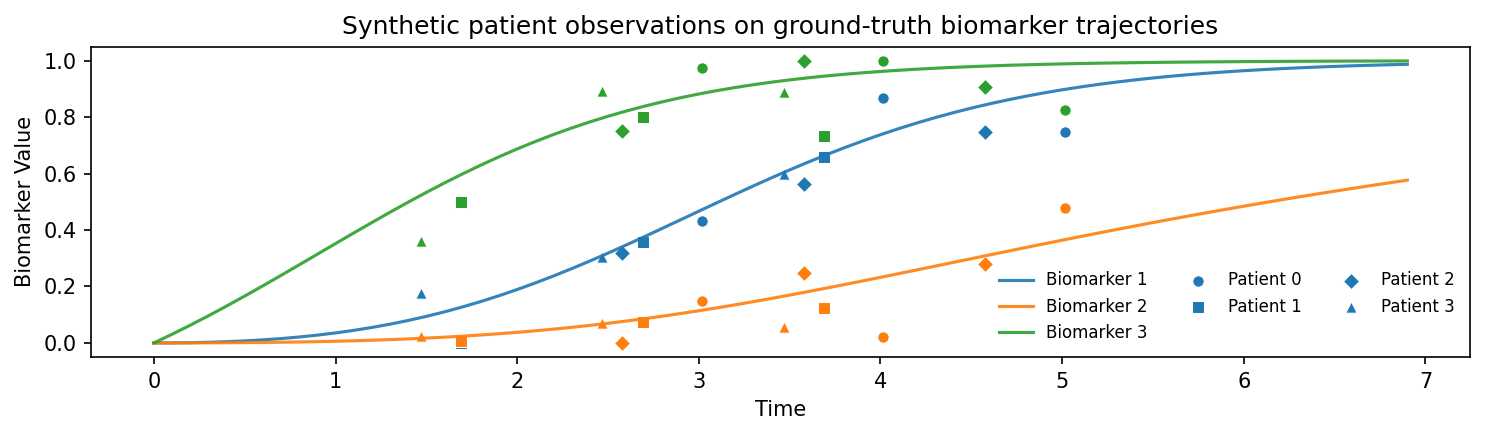

2.0825497783678255
SUBTYPE 1:
f: [0.3 0.  0. ]
a = 1.1927249100009507, b = 6.8096301386771785


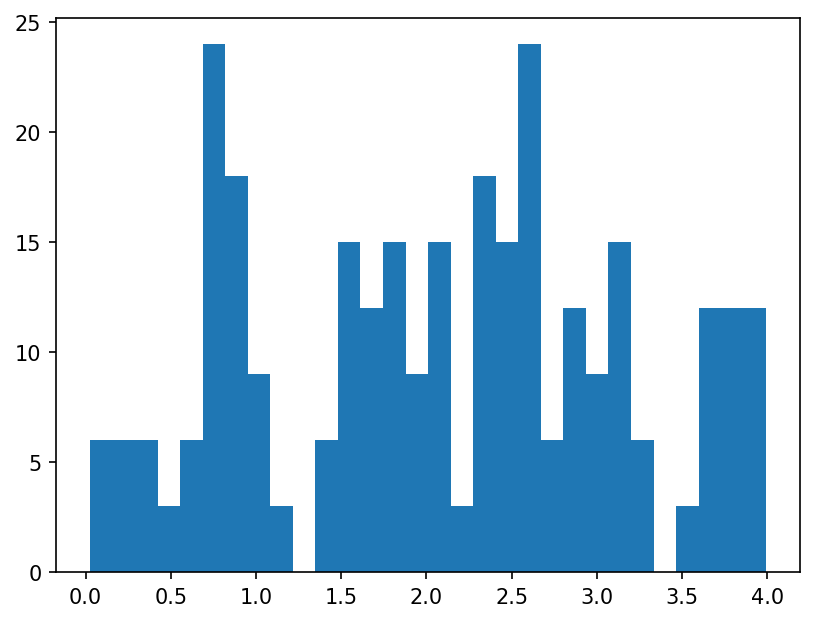

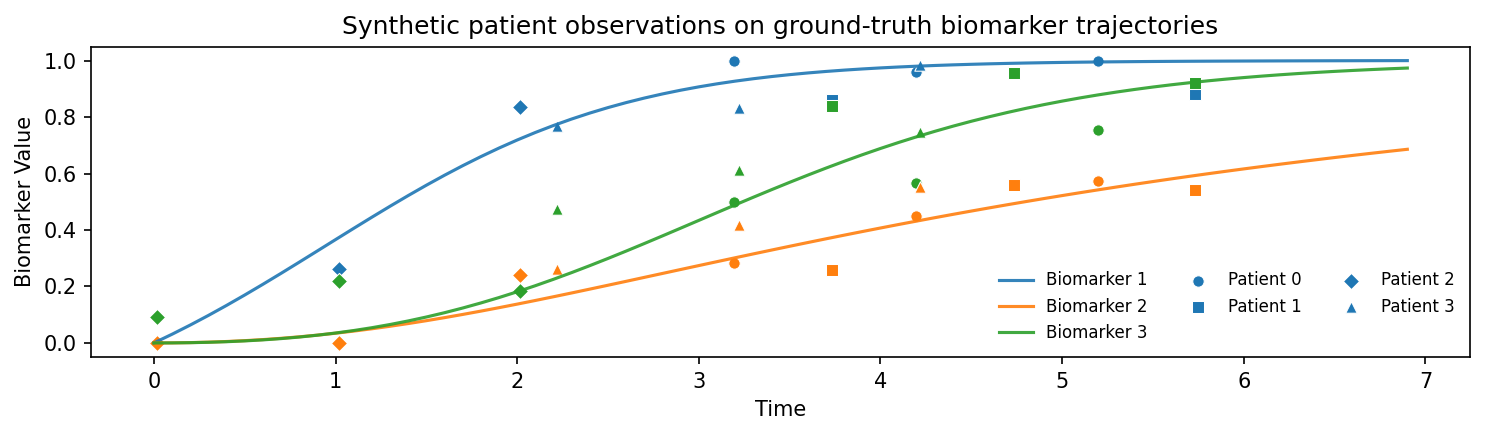

1.980709205848541
SUBTYPE 2:
f: [0.  0.3 0. ]
a = 3.0026725053615246, b = 4.680674259481151


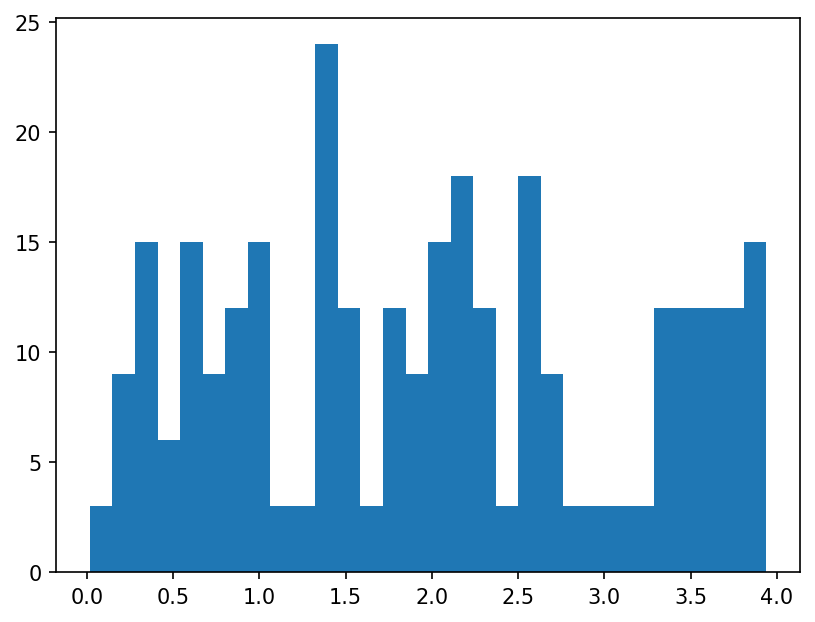

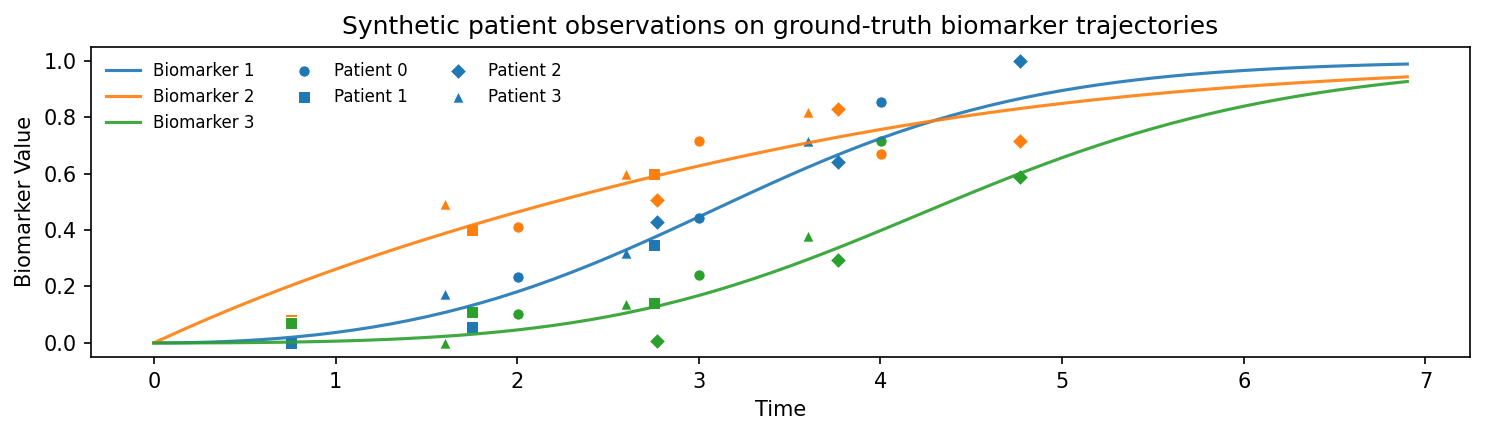

2.006035437041956


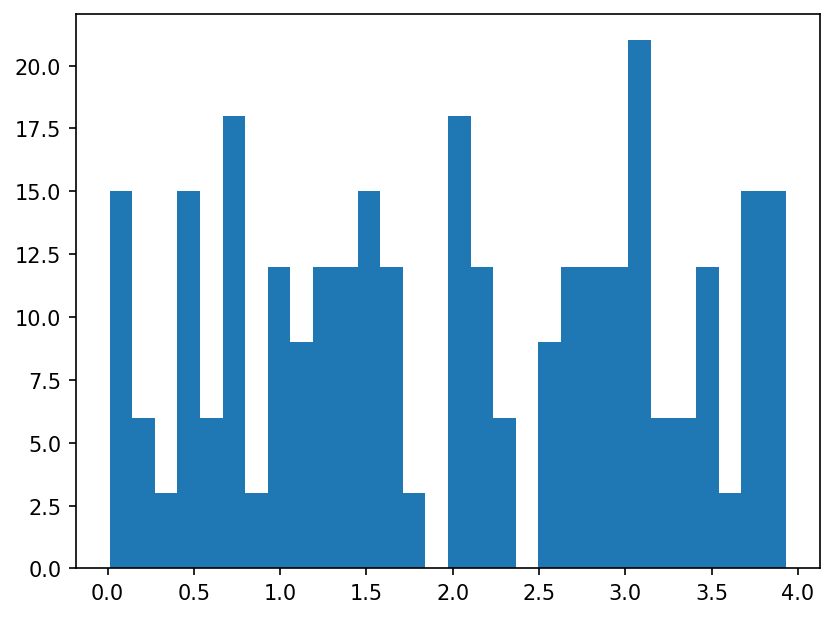

In [10]:
scalar_K_list = [0.2, 0.2, 0.2]
f_list = []
for _ in range(n_subtypes):
    f_list.append(rng.gamma(shape=2, scale=0.005, size=n_biomarkers))

f_list = [np.array([0.0, 0.0, 0.3]), np.array([0.3, 0.0, 0.0]), np.array([0.0, 0.3, 0.0])]

X = []
y = []

for subtype in range(n_subtypes):
    print(f"SUBTYPE {subtype}:")
    t, x_true, K, x0, f, scalar_K, kappa_true  = generate_logistic_model(
        n_biomarkers=n_biomarkers,
        scalar_K=scalar_K_list[subtype],
        t_max=t_max,
        K=K,
        f=f_list[subtype],
        kappa=true_kappa,
    )

    print(f"f: {f}")
    
    df, cog_a, cog_b = generate_synthetic_data(
        n_biomarkers = n_biomarkers,
        t_max = t_max, 
        noise_level = noise_level,
        n_patients = n_patients,
        n_patient_obs = n_patient_obs,
        x_true=x_true, 
        t=t,
        rng = np.random.RandomState(75 + subtype + 2),
    )

    plot_true_observations(df, t, x_true, patient_idx=[0,1,2,3])

    biomarker_cols = [col for col in df.columns if col.startswith("biomarker_")]

    X_obs = df[biomarker_cols].values   # (n_obs, n_biomarkers)
    dt = df["dt"].values                # (n_obs,)
    ids = df["patient_id"].values + subtype * n_patients # (n_obs,),  `+ subtype * n_patients` is for ensuring all ids are unique
    cog = df["cognitive_score"].values  # (n_obs,)
    beta_true = df["beta_true"].values  # (n_obs)
    
    plt.hist(beta_true, bins=30)
    print(np.mean(beta_true))
    
    X_subtype = create_patient_list(X_obs, ids, dt, cog, initial_beta=None)
    
    for p in X_subtype: # tag each patient with true subtype for later eval
        p["subtype_true"] = int(subtype)
    X += X_subtype # pythonic concatenate list syntactic sugar
    
    y.append(beta_true[::n_patient_obs] )
    
X = np.asarray(X)
y = np.concatenate(y)


In [12]:
all_dt = np.concatenate([p["dt"] for p in X])
all_cog = np.concatenate([p["cog"] for p in X])
all_ids_array = np.concatenate([[p["id"]] * len(p["dt"]) for p in X])

initial_beta, pid_to_beta, result = fit_mixedlm_beta_from_clinical(
    ids=all_ids_array,
    dt=all_dt,
    cog=all_cog,
    t_max=t_max,
    verbose=True,
    rng=np.random.default_rng(75)
)

unique_ids = np.unique([p["id"] for p in X])
beta_true_array = y
        
print(f"Initialized beta for {len(initial_beta)} patients")
print(f"Beta range: [{np.min(initial_beta):.2f}, {np.max(initial_beta):.2f}]")
print(f"True beta range: [{np.min(beta_true_array):.2f}, {np.max(beta_true_array):.2f}]")


beta_init summary: count    300.000000
mean       3.042049
std        1.677473
min        0.000000
25%        1.745121
50%        2.600821
75%        4.085345
max        7.000000
dtype: float64
Initialized beta for 300 patients
Beta range: [0.00, 7.00]
True beta range: [0.01, 3.99]


## Grid Search with K-Fold Cross-Validation

We'll perform grid search over hyperparameters using K-fold cross-validation (not group k-fold).


In [13]:
# Initialize f for all models
f_init = initialize_f_eigen(K, n_subtypes=4, n_eigs=8, jitter=True, sparsity_mask=True, rng=np.random.RandomState(72))
if isinstance(f_init, list):
    f_init = f_init[0]

print(f_init)

# Add initial_beta to patient data
unique_ids = np.unique([p["id"] for p in X])
id_to_beta_idx = {pid: idx for idx, pid in enumerate(unique_ids)}
for p in X:
    p["initial_beta"] = initial_beta[id_to_beta_idx[p["id"]]]
    # SubjectEM also expects beta_pred (use initial_beta as starting point)
    p["beta_pred"] = float(initial_beta[id_to_beta_idx[p["id"]]])

# Add initialization fields required by SubjectEM (for burn-in initialization)
# These are used as starting points for the per-patient SubjectEM burn-in
s_init = np.ones(n_biomarkers)  # Default initialization for s
scalar_K_init = float(np.max([np.max(p["X_obs"]) for p in X]))  # Use max observed value

for p in X:
    p["f_init"] = f_init[0].copy()   # (3,) for SubjectEM  # Use the f_init from eigen initialization
    p["s_init"] = s_init.copy()
    p["scalar_K_init"] = scalar_K_init


[[0.7406 0.4637 0.    ]
 [0.6344 0.6321 0.    ]
 [0.     0.5158 0.7864]
 [0.8157 0.4777 0.    ]]


In [15]:
# Define parameter grid for grid search (n_subtypes fixed by BIC below)
param_grid = {
    "lambda_f": [1.0],
    "lambda_cog": [0.0],
    "lambda_scalar": [0.0],
    "lambda_jsd": [0],
    "lambda_kappa": [1.0],
    "epsilon": [1e-3],
    # Staged global/cluster θ optimizers (default if omitted: lbfgs_approx → nelder_mead)
    "theta_solver_stages": [("lbfgs_exact",)],
    "max_iter": [15],
    "t_max": [t_max],
    "step": [0.01],
    "K": [K],
    "rng": [np.random.default_rng(75)],
    "assignments_jitter": [False],
    "jitter_iter": [0],
    "verbose": [1],
}

print(f"Parameter grid size: {np.prod([len(v) for v in param_grid.values()])} combinations")
print(f"K-fold CV will be performed for each combination")


Parameter grid size: 1 combinations
K-fold CV will be performed for each combination


$$SSE_b = \sum_{r} \big( X_{obs} - X_{pred} \big)^2$$

In [16]:
import time
import cProfile, pstats, io
from sklearn.model_selection import GridSearchCV, KFold

# ----- debug/runtime-friendly settings -----
candidate_n_subtypes = [3]
n_splits = 2
kf = KFold(n_splits=n_splits, shuffle=True, random_state=75)

bic_per_K = {}
best_model_per_K = {}
best_params_per_K = {}
profile_per_K = {}

for K_val in candidate_n_subtypes:
    print(f"\nGridSearchCV for n_subtypes={K_val}")

    base_estimator = SubtypingEM(
        K=K,
        initial_f=f_init[:K_val],
        n_subtypes=K_val,
        theta_solver_stages=("lbfgs_approx", "lbfgs_exact", "nelder_mead"),
        max_iter=1000,      # lower temporarily if needed for profiling, e.g. 50-150
        t_max=t_max,
        step=0.01,
        epsilon=5e-2,
        lambda_f=0.545,
        lambda_cog=0.001,
        lambda_scalar=0.1,
        lambda_jsd=1.0,
        verbose=1,
        rng=np.random.default_rng(75),
    )

    grid = GridSearchCV(
        estimator=base_estimator,
        param_grid=param_grid,
        cv=kf,
        scoring=None,
        n_jobs=1,            # <- key workaround (avoid per-worker compile/runtime blowup)
        pre_dispatch=1,
        verbose=1,
        return_train_score=False,
    )

    pr = cProfile.Profile()
    t0 = time.perf_counter()
    pr.enable()
    grid.fit(X=X, y=None)
    pr.disable()
    elapsed = time.perf_counter() - t0

    best_est = grid.best_estimator_
    bic_val = best_est.bic_  # computed in fit() via model_selection.compute_bic
    bic_per_K[K_val] = bic_val
    best_model_per_K[K_val] = best_est
    best_params_per_K[K_val] = grid.best_params_

    print(f"  Best CV score: {grid.best_score_:.6f}, BIC: {bic_val:.4f}")
    print(f"  Elapsed: {elapsed/60:.2f} min")

    s = io.StringIO()
    pstats.Stats(pr, stream=s).sort_stats("cumtime").print_stats(40)
    profile_per_K[K_val] = s.getvalue()
    print("\nTop profiler entries:\n")
    print(profile_per_K[K_val][:4000])  # trim output length

best_n_subtypes = min(bic_per_K, key=bic_per_K.get)
best_model = best_model_per_K[best_n_subtypes]
print(f"\nBIC per K: {bic_per_K}")
print(f"Chosen n_subtypes: {best_n_subtypes} (lowest BIC)")

Exception ignored When destroying _lsprof profiler:
Traceback (most recent call last):
  File "/tmp/ipykernel_23575/3641086013.py", line 48, in <module>
RuntimeError: Cannot install a profile function while another profile function is being installed



GridSearchCV for n_subtypes=3
Fitting 2 folds for each of 1 candidates, totalling 2 fits


100%|██████████| 15/15 [01:04<00:00,  4.29s/it]

  Best CV score: -92.131857, BIC: 553.7797
  Elapsed: 2.74 min

Top profiler entries:

         86000820 function calls (86000133 primitive calls) in 164.434 seconds

   Ordered by: cumulative time
   List reduced from 771 to 40 due to restriction <40>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1    0.000    0.000  164.434  164.434 /home/dsemchin/miniconda3/envs/comind/lib/python3.10/site-packages/sklearn/base.py:1348(wrapper)
        1    0.000    0.000  164.434  164.434 /home/dsemchin/miniconda3/envs/comind/lib/python3.10/site-packages/sklearn/model_selection/_search.py:914(fit)
        3    0.000    0.000  160.151   53.384 /home/dsemchin/COMIND/COMIND_transformer/subtyping_em_transformer.py:165(fit)
        3    0.002    0.001  159.954   53.318 /home/dsemchin/COMIND/COMIND_transformer/subtyping_em_transformer.py:502(_run_em_loop)
       45    0.013    0.000  159.845    3.552 /home/dsemchin/COMIND/COMIND_transformer/subtyping_em_transformer.py:59

In [17]:
# Best model and K were set in the previous cell (Option 1). Summary:
print(f"Best n_subtypes: {best_n_subtypes}")
print(f"Best params for chosen K: {best_params_per_K[best_n_subtypes]}")
print(f"BIC of best model: {best_model.bic_:.4f}")
if hasattr(best_model, 'lse_history') and len(best_model.lse_history) > 0:
    print(f"Final LSE: {best_model.lse_history[-1]:.6f}")

Best n_subtypes: 3
Best params for chosen K: {'K': array([[0.7256, 1.    , 0.7805],
       [1.    , 0.    , 0.1159],
       [0.7805, 0.1159, 0.6498]]), 'assignments_jitter': False, 'epsilon': 0.001, 'jitter_iter': 0, 'lambda_cog': 0.0, 'lambda_f': 1.0, 'lambda_jsd': 0, 'lambda_kappa': 1.0, 'lambda_scalar': 0.0, 'max_iter': 15, 'rng': Generator(PCG64) at 0x7F030A766C00, 'step': 0.01, 't_max': 7, 'theta_solver_stages': ('lbfgs_exact',), 'verbose': 1}
BIC of best model: 553.7797
Final LSE: 20.487708


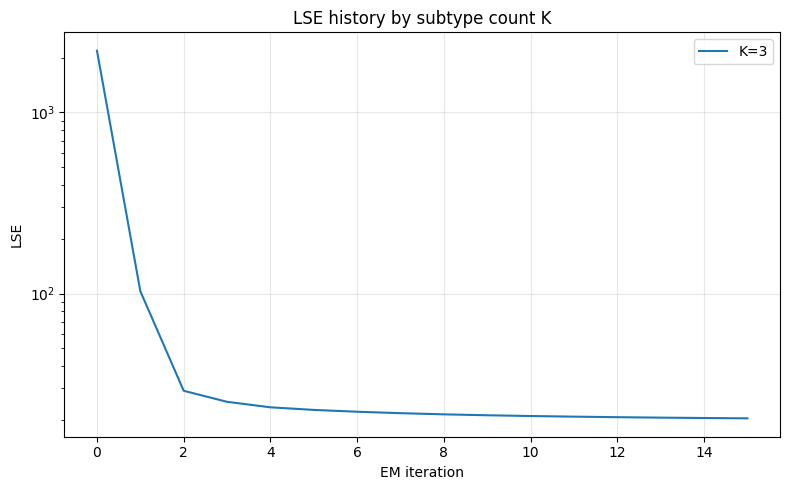

In [18]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
for K_val in candidate_n_subtypes:
    m = best_model_per_K[K_val]
    if hasattr(m, 'lse_history') and m.lse_history is not None and len(m.lse_history) > 0:
        ax.plot(m.lse_history, label=f'K={K_val}')
ax.set_xlabel('EM iteration')
ax.set_ylabel('LSE')
ax.set_title('LSE history by subtype count K')
ax.legend()
ax.grid(True, alpha=0.3)
plt.yscale('log')
plt.tight_layout()
plt.show()

## Evaluate Best Model

Now we'll evaluate the best model found by grid search on the full dataset.


In [19]:
# Get the best model and refit on full data
X_list = list(X) if isinstance(X, np.ndarray) else X
best_model = best_model_per_K[best_n_subtypes]
best_model.verbose = 1
best_model.fit(X_list)

print(f"\nBest model final LSE: {best_model.lse_history[-1]:.6f}")


100%|██████████| 15/15 [00:48<00:00,  3.23s/it]


Best model final LSE: 20.394956


In [31]:
# --- Save fitted results for fast replotting (run once after full fit) ---
import pickle
import numpy as np
from pathlib import Path

PLOT_CACHE = Path("synthetic_opt_sens_plot_cache.pkl")

# Requires: best_model, beta_true_array, X, and ground-truth objects from data-gen cells
fit_snapshot = {
    # scalar params
    "n_biomarkers": n_biomarkers,
    "n_subtypes": n_subtypes,
    "t_max": t_max,
    "t_span": t_span,
    "noise_level": noise_level,
    "n_patients": n_patients,
    "n_patient_obs": n_patient_obs,
    # ground truth
    "K": K,
    "true_kappa": np.asarray(true_kappa),
    "f_list": [np.asarray(f) for f in f_list],
    "scalar_K_list": list(scalar_K_list),
    "beta_true_array": np.asarray(beta_true_array),
    "X": list(X) if isinstance(X, np.ndarray) else X,
    # fitted model (arrays only — no SubtypingEM object)
    "beta_history": np.asarray(best_model.beta_history),
    "final_assignments": np.asarray(best_model.final_assignments),
    "cluster_f": [np.asarray(f) for f in best_model.cluster_f],
    "final_scalar_K": float(best_model.final_scalar_K),
    "final_kappa": np.asarray(best_model.final_kappa),
    "bic_": float(best_model.bic_),
    "subtype_mapping": np.asarray(
        best_model.compute_subtype_mapping(f_list, verbose=False)
    ),
}

with open(PLOT_CACHE, "wb") as f:
    pickle.dump(fit_snapshot, f, protocol=pickle.HIGHEST_PROTOCOL)

print(f"Saved plot cache -> {PLOT_CACHE.resolve()}")
print(f"BIC: {fit_snapshot['bic_']:.4f}")
print(f"subtype_mapping: {fit_snapshot['subtype_mapping']}")

Saved plot cache -> /home/dsemchin/COMIND/notebooks/synthetic-experiments/synthetic_opt_sens_plot_cache.pkl
BIC: 543.9663
subtype_mapping: [1 2 0]



Subtype mapping (fitted → true): [1 2 0]
  Fitted subtype 0 → True subtype 1
  Fitted subtype 1 → True subtype 2
  Fitted subtype 2 → True subtype 0
Overlap-based mapping (fitted → true): [1 2 0]

Fitted Subtype 0 -> True Subtype 1:
  f_fitted:      [0.3169 0.0311 0.019 ]
  f_true:        [0.3 0.  0. ]

Fitted Subtype 1 -> True Subtype 2:
  f_fitted:      [0.013  0.3017 0.0035]
  f_true:        [0.  0.3 0. ]

Fitted Subtype 2 -> True Subtype 0:
  f_fitted:      [0.0074 0.0093 0.2492]
  f_true:        [0.  0.  0.3]

Global scalar_K:
  scalar_K_fitted: 0.155079
  scalar_K_true (mean): 0.200000
  scalar_K_true (per subtype): [0.2, 0.2, 0.2]

Global s:
  s_fitted:      [0.9909 0.9582 0.9775]
  s_true:        [1. 1. 1.]
Kappa:
	kappa_true: [6.5122e-01 1.5794e-10 6.0351e-01]
	kappa_fit: [0.7256 0.     0.6498]


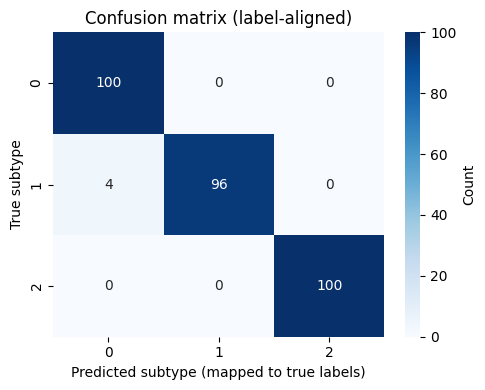

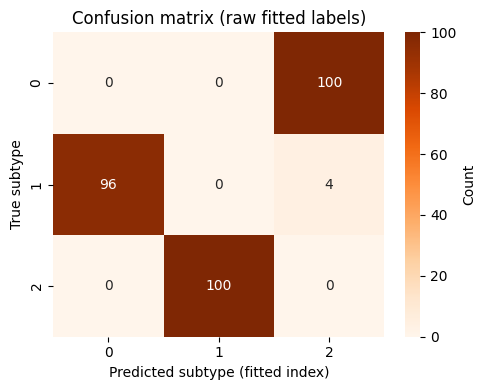


Adjusted Rand Index (mapped): 0.9605
BIC (training): 543.9663


In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
# Ensure list-of-dicts for evaluation helpers (utils.* imported in cell 1) (fit accepts list; avoid accidental np.asarray)
X_list = list(X) if isinstance(X, np.ndarray) else X

assignments_true = np.array([p["subtype_true"] for p in X_list])
beta_true_flat = np.ravel(np.asarray(beta_true_array))
n_true_subtypes = len(f_list)
n_fitted_subtypes = len(best_model.cluster_f)

# Fitted → true permutation via f matching (also on best_model.compute_subtype_mapping)
subtype_mapping = best_model.compute_subtype_mapping(f_list, verbose=True)
mapped_assignments = subtype_mapping[best_model.final_assignments]

# Optional cross-check: assignment overlap mapping (can differ slightly from f-based)
subtype_mapping_overlap = get_subtype_mapping(
    best_model.final_assignments, assignments_true
)
print(f"Overlap-based mapping (fitted → true): {subtype_mapping_overlap}")

print_parameter_comparison(
    fitted_f_list=best_model.cluster_f,
    fitted_scalar_K=best_model.final_scalar_K,
    fitted_s=best_model.final_s,
    true_f_list=f_list,
    true_scalar_K_list=scalar_K_list,
    true_s=np.ones(n_biomarkers),
    subtype_mapping=subtype_mapping,
    n_subtypes=n_fitted_subtypes,
)
print(f"Kappa:")
print(f"\tkappa_true: {best_model.final_kappa}")
print(f"\tkappa_fit: {true_kappa}")

# Confusion matrices (true subtype labels on rows)
true_tick = list(range(n_true_subtypes))

cm_mapped = confusion_matrix(
    assignments_true, mapped_assignments, labels=true_tick
)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm_mapped, annot=True, fmt="d", cmap="Blues", ax=ax,
    xticklabels=true_tick, yticklabels=true_tick,
    cbar_kws={"label": "Count"},
)
ax.set_xlabel("Predicted subtype (mapped to true labels)")
ax.set_ylabel("True subtype")
ax.set_title("Confusion matrix (label-aligned)")
plt.tight_layout()
plt.show()

fitted_tick = list(range(n_fitted_subtypes))
cm_raw = confusion_matrix(
    assignments_true, best_model.final_assignments, labels=fitted_tick
)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm_raw, annot=True, fmt="d", cmap="Oranges", ax=ax,
    xticklabels=fitted_tick, yticklabels=true_tick,
    cbar_kws={"label": "Count"},
)
ax.set_xlabel("Predicted subtype (fitted index)")
ax.set_ylabel("True subtype")
ax.set_title("Confusion matrix (raw fitted labels)")
plt.tight_layout()
plt.show()

ari = adjusted_rand_score(assignments_true, mapped_assignments)
print(f"\nAdjusted Rand Index (mapped): {ari:.4f}")
print(f"BIC (training): {best_model.bic_:.4f}")

In [21]:
# import seaborn as sns

# assignments_true = np.array([p["subtype_true"] for p in X])
# mapped_assignments = subtype_mapping[best_model.final_assignments]
# cm_mapped = confusion_matrix(assignments_true, mapped_assignments)

# fig, ax = plt.subplots(figsize=(3, 2.5))
# sns.heatmap(
#     cm_mapped,
#     annot=True,
#     fmt="d",
#     cmap="Blues",
#     ax=ax,
#     xticklabels=[0, 1, 2],
#     yticklabels=[0, 1, 2],
#     cbar_kws={"label": "Count"},
# )
# ax.set_xlabel("Predicted subtype", fontsize=9)
# ax.set_ylabel("True subtype", fontsize=9)
# ax.tick_params(axis="both", labelsize=8)
# plt.tight_layout()
# plt.savefig("confusion_matrix_mapped.pdf", bbox_inches="tight", dpi=300)
# plt.show()

In [22]:
if getattr(best_model, 'assignment_probabilities_', None) is not None:
    import matplotlib.pyplot as plt
    probs = best_model.assignment_probabilities_
    eps = 1e-12
    entropy_per_patient = -np.sum(probs * np.log(probs + eps), axis=1)
    mean_posterior_entropy = np.mean(entropy_per_patient)
    print(f"Mean posterior entropy: {mean_posterior_entropy:.4f}")
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].hist(np.max(probs, axis=1), bins=20)
    axes[0].set_xlabel('assignment probability (confidence)')
    axes[0].set_ylabel('count')
    axes[0].set_title('max assignment probability per patient')
    axes[1].hist(entropy_per_patient, bins=20)
    axes[1].set_xlabel('posterior entropy')
    axes[1].set_ylabel('count')
    axes[1].set_title('posterior entropy per patient')
    plt.tight_layout()
    plt.show()

## Visualizations


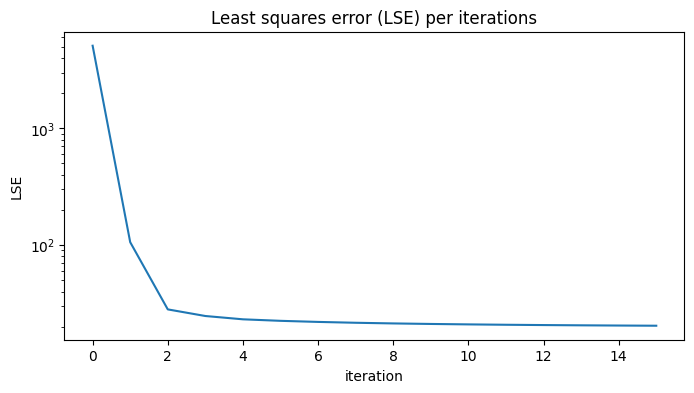

In [23]:
# Plot LSE history
plot_lse(best_model.lse_history)

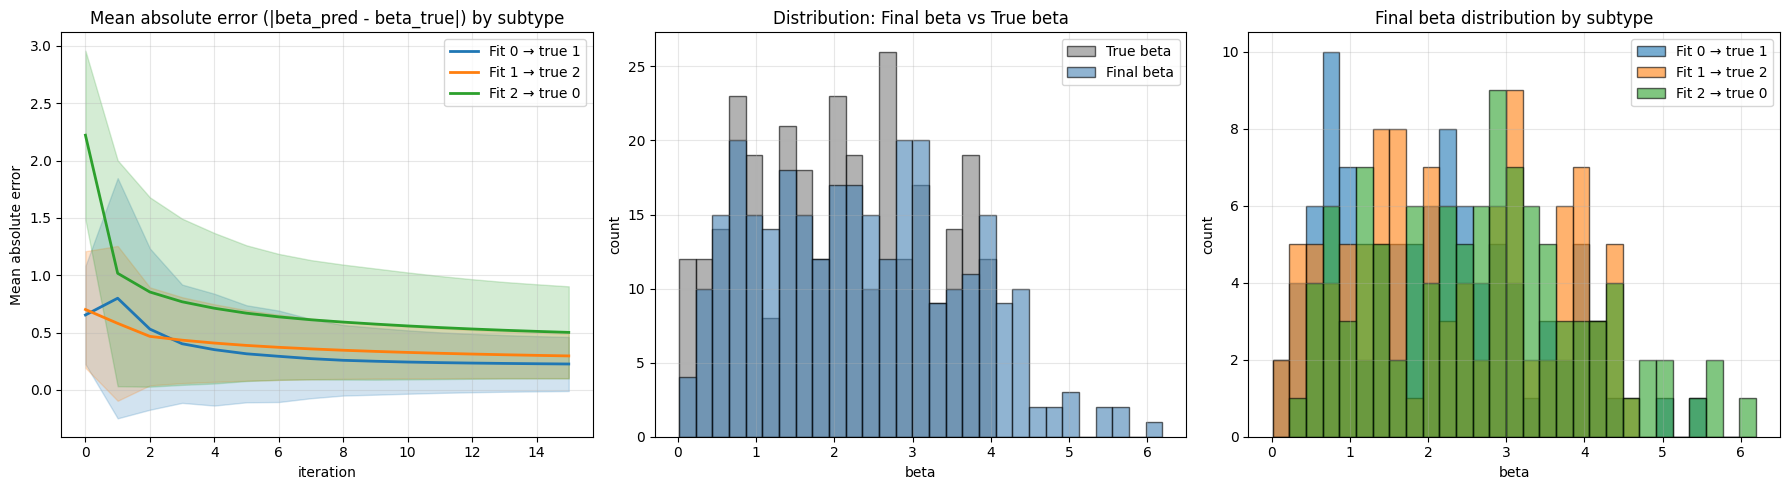

In [24]:
# Plot beta history by fitted subtype (legend shows f-based map to true)
fitted_labels = [
    f"Fit {i} → true {int(subtype_mapping[i])}" for i in range(n_fitted_subtypes)
]
plot_beta_history_by_subtype(
    beta_history=best_model.beta_history,
    assignments=best_model.final_assignments,
    n_subtypes=n_fitted_subtypes,
    beta_true=beta_true_flat,
    subtype_labels=fitted_labels,
)


In [25]:
# Mean |beta error| by TRUE subtype (using mapped assignments)

beta_pred = best_model.beta_history[:, -1]
if beta_true_flat.shape[0] != beta_pred.shape[0]:
    raise ValueError("beta_true_array length must match number of patients.")
abs_err = np.abs(beta_pred - beta_true_flat)

print("Mean |beta_pred - beta_true| ± std by TRUE subtype (final iteration):")
print("-" * 55)
for k in range(n_true_subtypes):
    mask = mapped_assignments == k
    if not np.any(mask):
        print(f"  True subtype {k}: (no patients)")
        continue
    ek = abs_err[mask]
    print(f"  True subtype {k}: {ek.mean():.4f} ± {ek.std(ddof=1):.4f}  (n = {ek.size})")
print("-" * 55)
print(f"  Overall:  {abs_err.mean():.4f} ± {abs_err.std(ddof=1):.4f}  (n = {abs_err.size})")

Mean |beta_pred - beta_true| ± std by TRUE subtype (final iteration):
-------------------------------------------------------
  True subtype 0: 0.5012 ± 0.4035  (n = 104)
  True subtype 1: 0.2257 ± 0.2369  (n = 96)
  True subtype 2: 0.2961 ± 0.1949  (n = 100)
-------------------------------------------------------
  Overall:  0.3447 ± 0.3168  (n = 300)


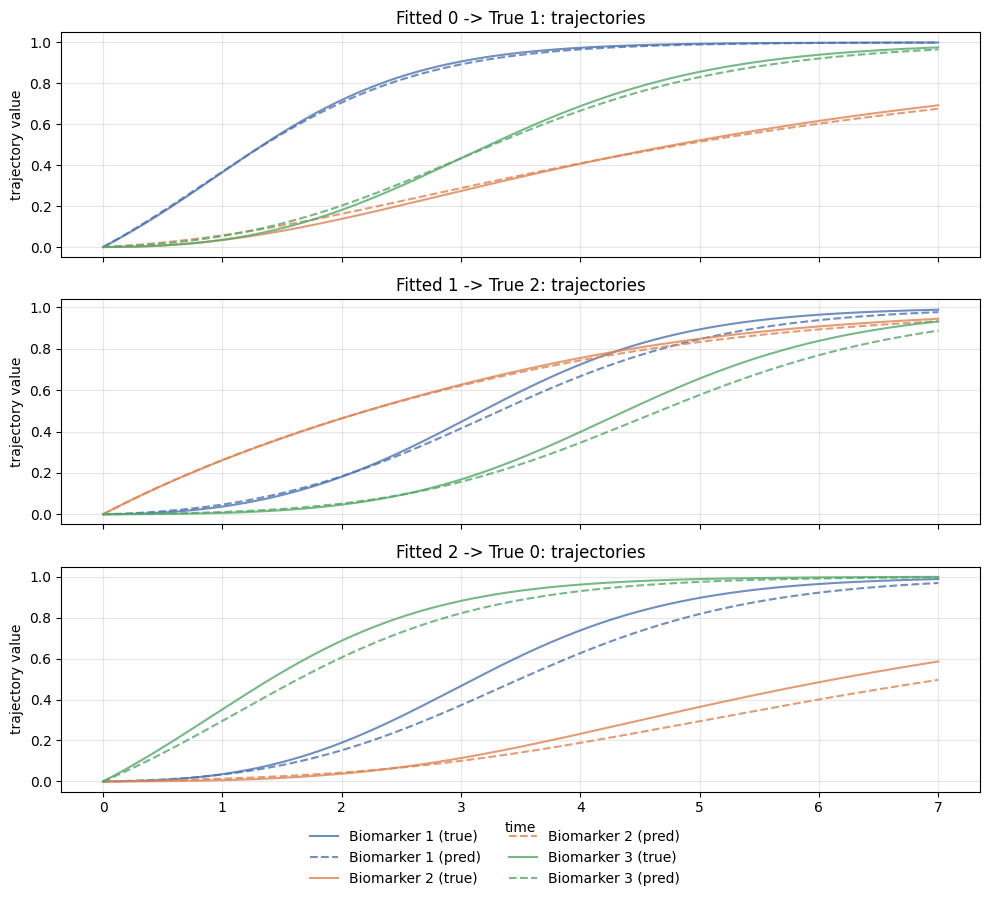

In [26]:
plot_true_vs_predicted_subtype_trajectories(
    n_subtypes=n_fitted_subtypes,
    f_true_list=f_list,
    scalar_K_true_list=scalar_K_list,
    f_pred_list=best_model.cluster_f,
    scalar_K_pred_list=[best_model.final_scalar_K] * n_fitted_subtypes,
    K=K,
    t_span=t_span,
    n_biomarkers=n_biomarkers,
    solve_system_fn=solve_system,
    subtype_mapping=subtype_mapping,
    kappa_true=true_kappa,
    kappa_pred=best_model.final_kappa,
)

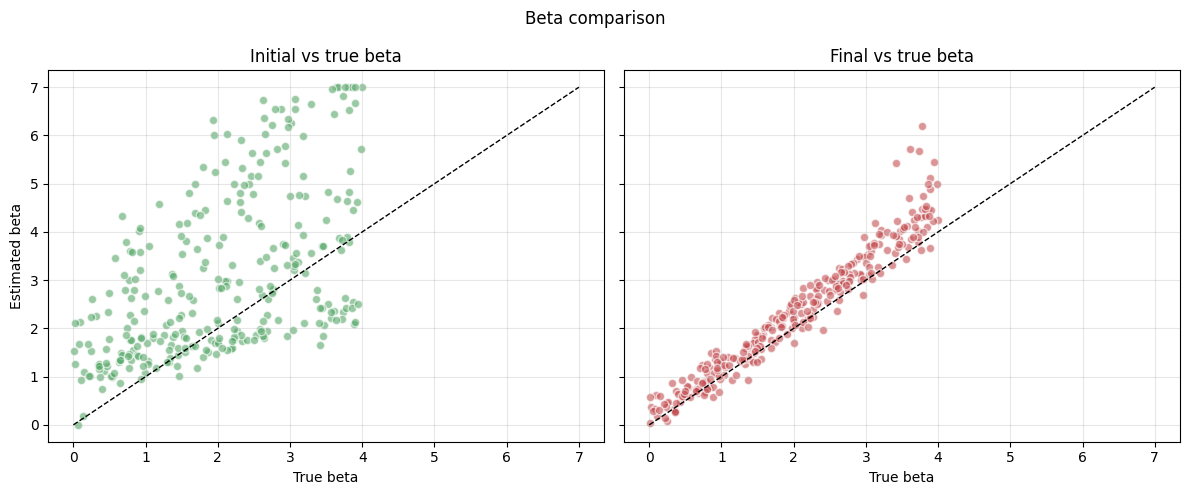

In [27]:
# Plot beta comparison (init vs final vs true)
beta_init_array = np.array([p.get("initial_beta", np.nan) for p in X_list])
if np.any(np.isnan(beta_init_array)):
    beta_init_array = initial_beta

beta_final_array = best_model.beta_history[:, -1]
plot_beta_comparison(beta_true_flat, beta_init_array, beta_final_array)


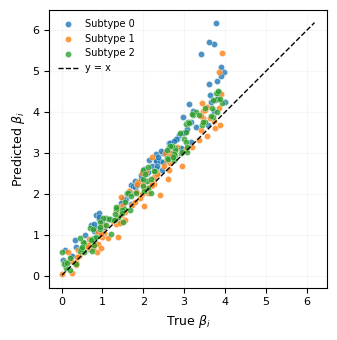

In [28]:
import matplotlib.pyplot as plt
import numpy as np

# Scatter colored by TRUE subtype (after f-based label mapping)
beta_pred = best_model.beta_history[:, -1]

fig, ax = plt.subplots(figsize=(3.5, 3.5))
colors = plt.get_cmap("tab10").colors

for k in range(n_true_subtypes):
    mask = mapped_assignments == k
    if not np.any(mask):
        continue
    ax.scatter(
        beta_true_flat[mask],
        beta_pred[mask],
        c=[colors[k % len(colors)]],
        label=f"Subtype {k}",
        s=20,
        alpha=0.8,
        edgecolors="white",
        linewidths=0.3,
    )

# Diagonal (perfect prediction)
lims = [
    min(beta_true_flat.min(), beta_pred.min()),
    max(beta_true_flat.max(), beta_pred.max()),
]
ax.plot(lims, lims, "k--", linewidth=1, label="y = x")

ax.set_xlabel(r"True $\beta_i$", fontsize=9)
ax.set_ylabel(r"Predicted $\beta_i$", fontsize=9)
ax.tick_params(axis="both", labelsize=8)
ax.set_aspect("equal")
ax.legend(fontsize=7, frameon=False)
ax.grid(True, alpha=0.1)
plt.tight_layout()
#plt.savefig("beta_true_vs_pred.pdf", bbox_inches="tight", dpi=300)
plt.show()

In [14]:
# --- Restore cached fit (skip grid search + refit) ---
import pickle
import numpy as np
from pathlib import Path
from types import SimpleNamespace

PLOT_CACHE = Path("synthetic_opt_sens_plot_cache.pkl")
USE_CACHED_FIT = True   # set False to run the real fitting cells again

class _CachedBestModel(SimpleNamespace):
    """Minimal stand-in for SubtypingEM with only what the plot cells need."""

    def compute_subtype_mapping(self, true_f_list, verbose=False):
        if self.subtype_mapping is not None:
            return self.subtype_mapping
        from COMIND_transformer.utils import get_subtype_mapping_from_f
        self.subtype_mapping = get_subtype_mapping_from_f(self.cluster_f, true_f_list)
        if verbose:
            print(f"\nSubtype mapping (fitted → true): {self.subtype_mapping}")
        return self.subtype_mapping


def restore_plot_cache(path=PLOT_CACHE):
    with open(path, "rb") as f:
        snap = pickle.load(f)

    # params + ground truth
    globals().update({
        "n_biomarkers": snap["n_biomarkers"],
        "n_subtypes": snap["n_subtypes"],
        "t_max": snap["t_max"],
        "t_span": snap["t_span"],
        "noise_level": snap["noise_level"],
        "n_patients": snap["n_patients"],
        "n_patient_obs": snap["n_patient_obs"],
        "K": snap["K"],
        "true_kappa": snap["true_kappa"],
        "f_list": snap["f_list"],
        "scalar_K_list": snap["scalar_K_list"],
        "beta_true_array": snap["beta_true_array"],
        "X": snap["X"],
    })

    best_model = _CachedBestModel(
        beta_history=snap["beta_history"],
        final_assignments=snap["final_assignments"],
        cluster_f=snap["cluster_f"],
        final_scalar_K=snap["final_scalar_K"],
        final_kappa=snap["final_kappa"],
        bic_=snap["bic_"],
        subtype_mapping=snap.get("subtype_mapping"),
    )
    return best_model


if USE_CACHED_FIT:
    if not PLOT_CACHE.exists():
        raise FileNotFoundError(
            f"{PLOT_CACHE} not found. Run the SAVE cell once after a full fit."
        )
    best_model = restore_plot_cache()
    print(f"Loaded cached fit from {PLOT_CACHE}")
    print(f"BIC: {best_model.bic_:.4f}")
    print(f"subtype_mapping: {best_model.subtype_mapping}")
else:
    print("USE_CACHED_FIT=False — run the fitting cells as usual.")

Loaded cached fit from synthetic_opt_sens_plot_cache.pkl
BIC: 543.9663
subtype_mapping: [1 2 0]


a = 4.676436127196727, b = 6.421955999238555
a = 1.1927249100009507, b = 6.8096301386771785
a = 3.0026725053615246, b = 4.680674259481151


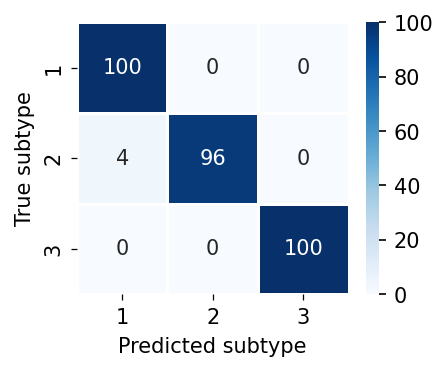

In [15]:
# --- Springer-style publication figures (square, high DPI, 1-indexed subtypes) ---
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D
import seaborn as sns

# Reset to matplotlib defaults (including default font), keep only export DPI
mpl.rcdefaults()
mpl.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

SQUARE = 3.25          # inches per square panel
PATIENT_IDX = [0, 1]   # patients 1 and 2 (0-indexed in df)
MARKERS = ["o", "s"]
BIOMARKER_COLORS = list(plt.get_cmap("tab10").colors[:n_biomarkers])
SUBTYPE_COLORS = list(plt.get_cmap("tab10").colors)
SUBTYPE_TICKS = list(range(1, n_subtypes + 1))  # 1-indexed labels

# --- Reuse / rebuild eval quantities (safe for Run All) ---
X_list = list(X) if isinstance(X, np.ndarray) else X
assignments_true = np.array([p["subtype_true"] for p in X_list])
beta_true_flat = np.ravel(np.asarray(beta_true_array))
beta_pred = best_model.beta_history[:, -1]

n_true_subtypes = len(f_list)
n_fitted_subtypes = len(best_model.cluster_f)
subtype_mapping = best_model.compute_subtype_mapping(f_list, verbose=False)
mapped_assignments = subtype_mapping[best_model.final_assignments]
fitted_for_true = {int(t): int(f) for f, t in enumerate(subtype_mapping)}

# Regenerate per-subtype ground truth (same RNG seeds as data-generation cell)
_subtype_pack = []
for subtype in range(n_subtypes):
    t_sub, x_true_sub, _, _, _, _, _ = generate_logistic_model(
        n_biomarkers=n_biomarkers,
        scalar_K=scalar_K_list[subtype],
        t_max=t_max,
        K=K,
        f=f_list[subtype],
        kappa=true_kappa,
    )
    df_sub, _, _ = generate_synthetic_data(
        n_biomarkers=n_biomarkers,
        t_max=t_max,
        noise_level=noise_level,
        n_patients=n_patients,
        n_patient_obs=n_patient_obs,
        x_true=x_true_sub,
        t=t_sub,
        rng=np.random.RandomState(75 + subtype + 2),
    )
    _subtype_pack.append((t_sub, x_true_sub, df_sub))


def _style_square_ax(ax):
    ax.set_box_aspect(1)
    #ax.grid(True, alpha=0.2, linewidth=0.5)
    ax.tick_params(length=3, width=0.6)


# ---------------------------------------------------------------------------
# 1) Label-aligned confusion matrix (no title)
# ---------------------------------------------------------------------------
cm_mapped = confusion_matrix(
    assignments_true, mapped_assignments, labels=list(range(n_true_subtypes))
)
fig_cm, ax_cm = plt.subplots(figsize=(SQUARE, SQUARE))
sns.heatmap(
    cm_mapped,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar_kws={"label": "Count", "shrink": 0.8},
    xticklabels=SUBTYPE_TICKS,
    yticklabels=SUBTYPE_TICKS,
    ax=ax_cm,
    linewidths=0.5,
    linecolor="white",
)
ax_cm.set_xlabel("Predicted subtype")
ax_cm.set_ylabel("True subtype")
_style_square_ax(ax_cm)
plt.tight_layout()
cbar = ax_cm.collections[0].colorbar
cbar.ax.set_ylabel("")  # ensure no label
cbar.ax.set_position([
    cbar.ax.get_position().x0,
    ax_cm.get_position().y0,
    cbar.ax.get_position().width,
    ax_cm.get_position().height,
])
fig_cm.savefig("fig_confusion_mapped.pdf", bbox_inches="tight")
fig_cm.savefig("fig_confusion_mapped.png", bbox_inches="tight")
plt.show()


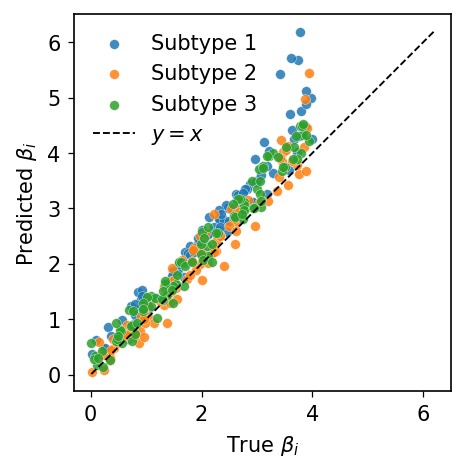

In [16]:


# ---------------------------------------------------------------------------
# 2) True vs predicted beta (no title, 1-indexed legend)
# ---------------------------------------------------------------------------
fig_beta, ax_beta = plt.subplots(figsize=(SQUARE, SQUARE))
for k in range(n_true_subtypes):
    mask = mapped_assignments == k
    if not np.any(mask):
        continue
    ax_beta.scatter(
        beta_true_flat[mask],
        beta_pred[mask],
        c=[SUBTYPE_COLORS[k % len(SUBTYPE_COLORS)]],
        s=22,
        alpha=0.85,
        edgecolors="white",
        linewidths=0.2,
        label=f"Subtype {k + 1}",
    )

lims = [
    min(beta_true_flat.min(), beta_pred.min()),
    max(beta_true_flat.max(), beta_pred.max()),
]
ax_beta.plot(lims, lims, "k--", linewidth=0.9, label=r"$y=x$")
ax_beta.set_xlabel(r"True $\beta_i$")
ax_beta.set_ylabel(r"Predicted $\beta_i$")
ax_beta.set_aspect("equal", adjustable="box")
ax_beta.legend(frameon=False, loc="upper left")
_style_square_ax(ax_beta)
plt.tight_layout()
fig_beta.savefig("fig_beta_true_vs_pred.pdf", bbox_inches="tight")
fig_beta.savefig("fig_beta_true_vs_pred.png", bbox_inches="tight")
plt.show()



/tmp/ipykernel_30987/19515014.py:94: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


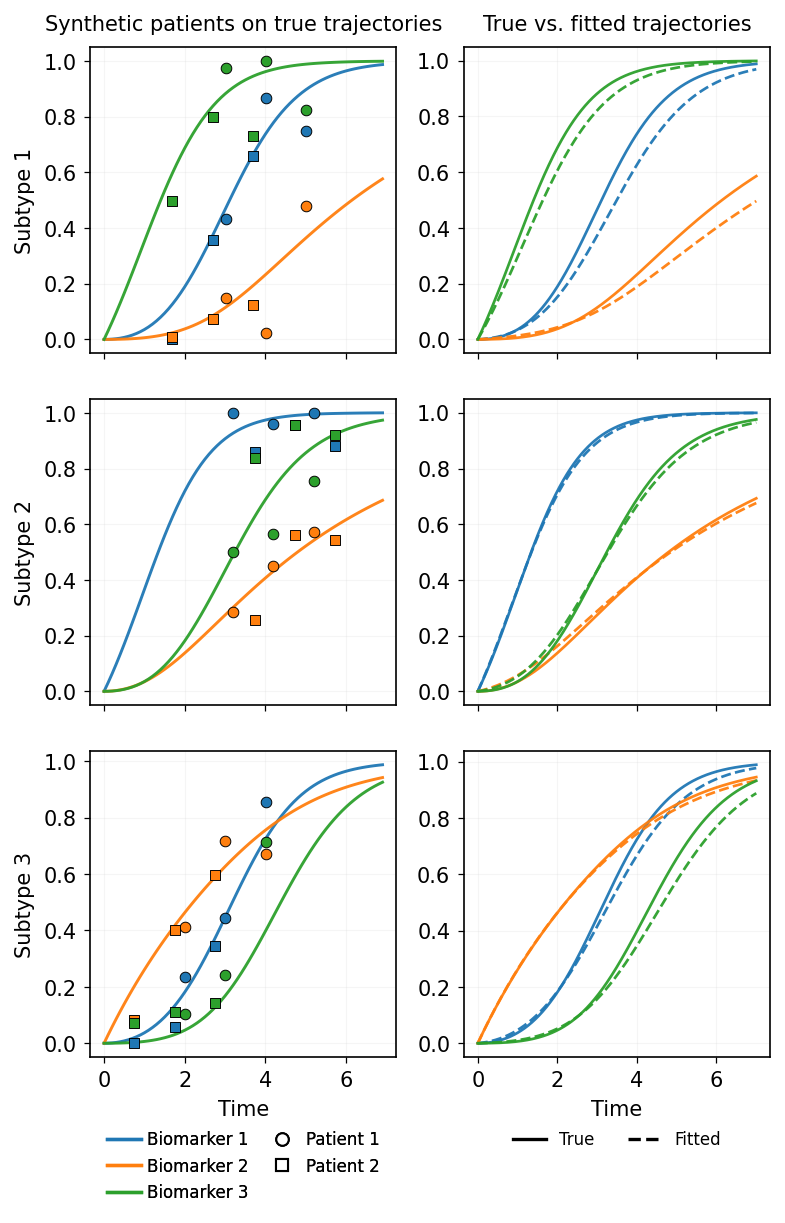

Adjusted Rand Index (mapped): 0.9605
BIC (training): 543.9663


In [17]:
# ---------------------------------------------------------------------------
# 3) 3×2 trajectories: col1 observations on truth, col2 true vs fitted
# ---------------------------------------------------------------------------
PANEL_W = SQUARE * 0.9   # slightly wider panels

fig_traj, axes = plt.subplots(
    n_subtypes, 2,
    figsize=(2 * PANEL_W, n_subtypes * SQUARE),
    sharex="col",
    gridspec_kw={"wspace": 0.22, "hspace": 0.10},
)

if n_subtypes == 1:
    axes = np.array([axes])

kappa_pred_arr = np.asarray(best_model.final_kappa, dtype=float)
kappa_true_arr = np.asarray(true_kappa, dtype=float)

for row, true_s in enumerate(range(n_subtypes)):
    t_sub, x_true_sub, df_sub = _subtype_pack[true_s]
    ax_obs, ax_fit = axes[row, 0], axes[row, 1]

    # --- Column 1: synthetic patients on true trajectories ---
    for b in range(n_biomarkers):
        ax_obs.plot(
            t_sub, x_true_sub[b],
            color=BIOMARKER_COLORS[b],
            linewidth=1.4,
            alpha=0.95,
        )
    for p_i, patient in enumerate(PATIENT_IDX):
        pdata = df_sub[df_sub["patient_id"] == patient]
        t_ij = pdata["beta_true"].to_numpy() + pdata["dt"].to_numpy()
        marker = MARKERS[p_i % len(MARKERS)]
        for b in range(n_biomarkers):
            ax_obs.scatter(
                t_ij,
                pdata[f"biomarker_{b + 1}"].to_numpy(),
                s=26,
                marker=marker,
                facecolors=BIOMARKER_COLORS[b],
                edgecolors="black",
                linewidths=0.45,
                zorder=3,
            )

    ax_obs.set_ylabel(f"Subtype {true_s + 1}")
    _style_square_ax(ax_obs)
    ax_obs.grid(True, alpha=0.25, linewidth=0.5, color="0.85")
    if row < n_subtypes - 1:
        ax_obs.tick_params(labelbottom=False)

    # --- Column 2: true vs fitted (same biomarker colors as column 1) ---
    f_fit = fitted_for_true[true_s]
    f_true = np.asarray(f_list[true_s])
    f_pred = np.asarray(best_model.cluster_f[f_fit])
    scalar_true = float(scalar_K_list[true_s])
    scalar_pred = float(best_model.final_scalar_K)

    traj_true = solve_system(
        np.zeros(n_biomarkers), f_true, K, t_span, scalar_true, kappa_true_arr
    )
    traj_pred = solve_system(
        np.zeros(n_biomarkers), f_pred, K, t_span, scalar_pred, kappa_pred_arr
    )

    for b in range(n_biomarkers):
        ax_fit.plot(
            t_span, traj_true[b],
            color=BIOMARKER_COLORS[b],
            linewidth=1.3,
            alpha=0.95,
        )
        ax_fit.plot(
            t_span, traj_pred[b],
            color=BIOMARKER_COLORS[b],
            linewidth=1.3,
            linestyle="--",
            alpha=0.95,
        )

    _style_square_ax(ax_fit)
    ax_fit.grid(True, alpha=0.25, linewidth=0.5, color="0.85")
    if row < n_subtypes - 1:
        ax_fit.tick_params(labelbottom=False)
    else:
        ax_obs.set_xlabel("Time")
        ax_fit.set_xlabel("Time")

# Column titles (top row only)
axes[0, 0].set_title("Synthetic patients on true trajectories", pad=8, fontsize=10)
axes[0, 1].set_title("True vs. fitted trajectories", pad=8, fontsize=10)

plt.tight_layout()
plt.subplots_adjust(bottom=0.18)

pos_left = axes[-1, 0].get_position()
pos_right = axes[-1, 1].get_position()
legend_y = min(pos_left.y0, pos_right.y0) - 0.04
x_left = 0.5 * (pos_left.x0 + pos_left.x1)
x_right = 0.5 * (pos_right.x0 + pos_right.x1)

bio_handles = [
    Line2D([0], [0], color=BIOMARKER_COLORS[b], lw=1.6, label=f"Biomarker {b + 1}")
    for b in range(n_biomarkers)
]
pat_handles = [
    Line2D(
        [0], [0], marker=MARKERS[i], linestyle="None",
        markerfacecolor="white", markeredgecolor="black",
        markersize=6, label=f"Patient {i + 1}",
    )
    for i in range(len(PATIENT_IDX))
]
leg_obs = fig_traj.legend(
    handles=bio_handles + pat_handles,
    loc="upper center",
    bbox_to_anchor=(x_left, legend_y),
    bbox_transform=fig_traj.transFigure,
    ncol=2,
    frameon=False,
    fontsize=8,
    columnspacing=1.0,
    handletextpad=0.4,
)

fit_handles = [
    Line2D([0], [0], color="black", lw=1.6, label="True"),
    Line2D([0], [0], color="black", lw=1.6, linestyle="--", label="Fitted"),
]
leg_fit = fig_traj.legend(
    handles=fit_handles,
    loc="upper center",
    bbox_to_anchor=(x_right, legend_y),
    bbox_transform=fig_traj.transFigure,
    ncol=2,
    frameon=False,
    fontsize=8,
)
fig_traj.add_artist(leg_obs)

fig_traj.savefig("fig_trajectories_3x2.pdf", bbox_inches="tight")
fig_traj.savefig("fig_trajectories_3x2.png", bbox_inches="tight")
plt.show()

print(f"Adjusted Rand Index (mapped): {adjusted_rand_score(assignments_true, mapped_assignments):.4f}")
print(f"BIC (training): {best_model.bic_:.4f}")

a = 4.676436127196727, b = 6.421955999238555
a = 1.1927249100009507, b = 6.8096301386771785
a = 3.0026725053615246, b = 4.680674259481151


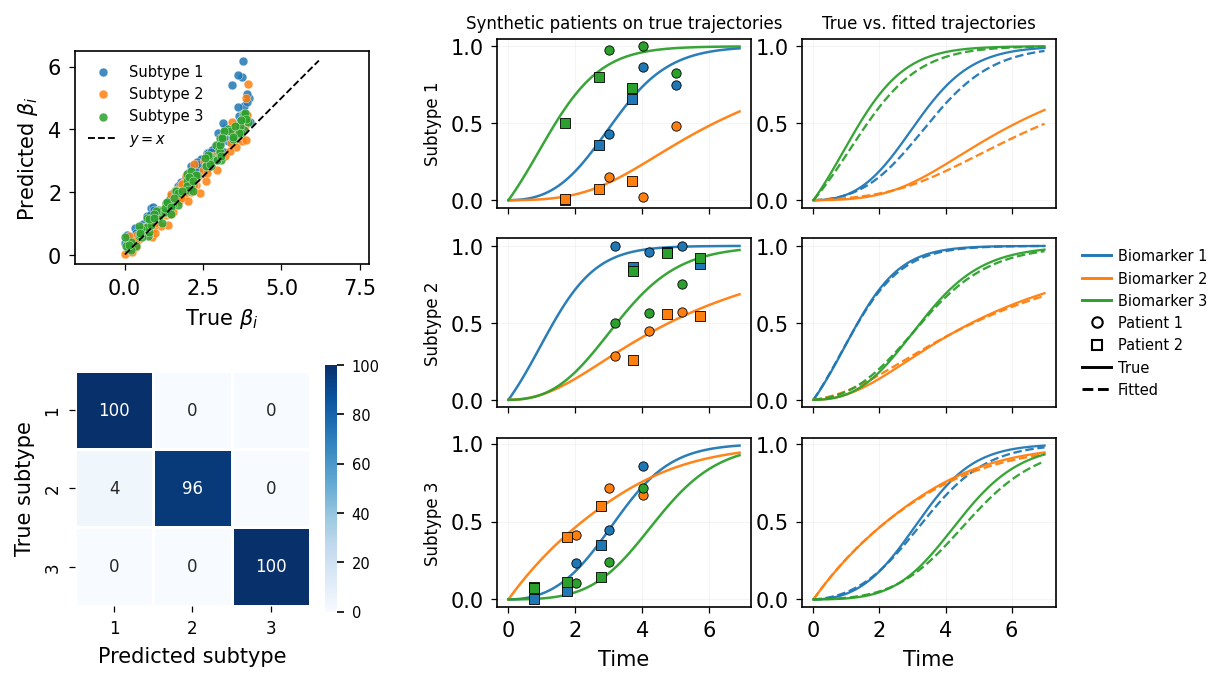

Adjusted Rand Index (mapped): 0.9605
BIC (training): 543.9663


In [20]:
# ---------------------------------------------------------------------------
# Combined figure: beta (top-left), confusion (bottom-left), trajectories (right)
# ---------------------------------------------------------------------------
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D
import seaborn as sns
from sklearn.metrics import confusion_matrix, adjusted_rand_score

mpl.rcdefaults()
mpl.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

PATIENT_IDX = [0, 1]
MARKERS = ["o", "s"]
BIOMARKER_COLORS = list(plt.get_cmap("tab10").colors[:n_biomarkers])
SUBTYPE_COLORS = list(plt.get_cmap("tab10").colors)
SUBTYPE_TICKS = list(range(1, n_subtypes + 1))

# --- Reuse / rebuild eval quantities (safe for Run All) ---
X_list = list(X) if isinstance(X, np.ndarray) else X
assignments_true = np.array([p["subtype_true"] for p in X_list])
beta_true_flat = np.ravel(np.asarray(beta_true_array))
beta_pred = best_model.beta_history[:, -1]

n_true_subtypes = len(f_list)
subtype_mapping = best_model.compute_subtype_mapping(f_list, verbose=False)
mapped_assignments = subtype_mapping[best_model.final_assignments]
fitted_for_true = {int(t): int(f) for f, t in enumerate(subtype_mapping)}

_subtype_pack = []
for subtype in range(n_subtypes):
    t_sub, x_true_sub, _, _, _, _, _ = generate_logistic_model(
        n_biomarkers=n_biomarkers,
        scalar_K=scalar_K_list[subtype],
        t_max=t_max,
        K=K,
        f=f_list[subtype],
        kappa=true_kappa,
    )
    df_sub, _, _ = generate_synthetic_data(
        n_biomarkers=n_biomarkers,
        t_max=t_max,
        noise_level=noise_level,
        n_patients=n_patients,
        n_patient_obs=n_patient_obs,
        x_true=x_true_sub,
        t=t_sub,
        rng=np.random.RandomState(75 + subtype + 2),
    )
    _subtype_pack.append((t_sub, x_true_sub, df_sub))

# --- Layout sizing ---
LEFT_W = 2.55
LEFT_H = 1.85
RIGHT_W = 4.85
ROW_H = 1.55
LEGEND_W = 0.95

FIG_W = LEFT_W + RIGHT_W + LEGEND_W + 0.55
FIG_H = max(2 * LEFT_H, n_subtypes * ROW_H) + 0.35

def _style_rect_ax(ax, box_aspect=0.72):
    ax.set_box_aspect(box_aspect)
    ax.tick_params(length=3, width=0.6)

def _style_square_ax_local(ax):
    ax.set_box_aspect(1.0)
    ax.tick_params(length=3, width=0.6)

fig = plt.figure(figsize=(FIG_W, FIG_H))
gs = fig.add_gridspec(
    2, 2,
    width_ratios=[LEFT_W, RIGHT_W],
    height_ratios=[LEFT_H, LEFT_H],
    wspace=0.30,
    hspace=0.34,
)

# --- Top left: true vs predicted beta ---
ax_beta = fig.add_subplot(gs[0, 0])
for k in range(n_true_subtypes):
    mask = mapped_assignments == k
    if not np.any(mask):
        continue
    ax_beta.scatter(
        beta_true_flat[mask],
        beta_pred[mask],
        c=[SUBTYPE_COLORS[k % len(SUBTYPE_COLORS)]],
        s=18,
        alpha=0.85,
        edgecolors="white",
        linewidths=0.2,
        label=f"Subtype {k + 1}",
    )

lims = [
    min(beta_true_flat.min(), beta_pred.min()),
    max(beta_true_flat.max(), beta_pred.max()),
]
ax_beta.plot(lims, lims, "k--", linewidth=0.9, label=r"$y=x$")
ax_beta.set_xlabel(r"True $\beta_i$")
ax_beta.set_ylabel(r"Predicted $\beta_i$")
ax_beta.set_aspect("equal", adjustable="box")
ax_beta.legend(frameon=False, loc="upper left", fontsize=7)
_style_rect_ax(ax_beta, box_aspect=LEFT_H / LEFT_W)

# --- Bottom left: confusion matrix (square) ---
ax_cm = fig.add_subplot(gs[1, 0])
cm_mapped = confusion_matrix(
    assignments_true, mapped_assignments, labels=list(range(n_true_subtypes))
)
sns.heatmap(
    cm_mapped,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar_kws={"shrink": 1.0},
    xticklabels=SUBTYPE_TICKS,
    yticklabels=SUBTYPE_TICKS,
    ax=ax_cm,
    linewidths=0.5,
    linecolor="white",
    annot_kws={"size": 8},
)
ax_cm.set_xlabel("Predicted subtype")
ax_cm.set_ylabel("True subtype")
ax_cm.tick_params(labelsize=8)
_style_square_ax_local(ax_cm)

cbar = ax_cm.collections[0].colorbar
cbar.ax.set_ylabel("")
cbar.ax.tick_params(labelsize=7)
cbar.ax.set_position([
    cbar.ax.get_position().x0,
    ax_cm.get_position().y0,
    cbar.ax.get_position().width,
    ax_cm.get_position().height,
])

# --- Right: 3x2 trajectories ---
gs_right = gs[:, 1].subgridspec(
    n_subtypes, 2,
    wspace=0.20,
    hspace=0.12,
)
axes = np.empty((n_subtypes, 2), dtype=object)
for row in range(n_subtypes):
    for col in range(2):
        axes[row, col] = fig.add_subplot(gs_right[row, col])

kappa_pred_arr = np.asarray(best_model.final_kappa, dtype=float)
kappa_true_arr = np.asarray(true_kappa, dtype=float)

for row, true_s in enumerate(range(n_subtypes)):
    t_sub, x_true_sub, df_sub = _subtype_pack[true_s]
    ax_obs, ax_fit = axes[row, 0], axes[row, 1]

    for b in range(n_biomarkers):
        ax_obs.plot(
            t_sub, x_true_sub[b],
            color=BIOMARKER_COLORS[b],
            linewidth=1.2,
            alpha=0.95,
        )
    for p_i, patient in enumerate(PATIENT_IDX):
        pdata = df_sub[df_sub["patient_id"] == patient]
        t_ij = pdata["beta_true"].to_numpy() + pdata["dt"].to_numpy()
        marker = MARKERS[p_i % len(MARKERS)]
        for b in range(n_biomarkers):
            ax_obs.scatter(
                t_ij,
                pdata[f"biomarker_{b + 1}"].to_numpy(),
                s=20,
                marker=marker,
                facecolors=BIOMARKER_COLORS[b],
                edgecolors="black",
                linewidths=0.4,
                zorder=3,
            )

    ax_obs.set_ylabel(f"Subtype {true_s + 1}", fontsize=8)
    _style_rect_ax(ax_obs, box_aspect=ROW_H / (RIGHT_W * 0.48))
    ax_obs.grid(True, alpha=0.25, linewidth=0.5, color="0.85")
    if row < n_subtypes - 1:
        ax_obs.tick_params(labelbottom=False)

    f_fit = fitted_for_true[true_s]
    f_true = np.asarray(f_list[true_s])
    f_pred = np.asarray(best_model.cluster_f[f_fit])
    scalar_true = float(scalar_K_list[true_s])
    scalar_pred = float(best_model.final_scalar_K)

    traj_true = solve_system(
        np.zeros(n_biomarkers), f_true, K, t_span, scalar_true, kappa_true_arr
    )
    traj_pred = solve_system(
        np.zeros(n_biomarkers), f_pred, K, t_span, scalar_pred, kappa_pred_arr
    )

    for b in range(n_biomarkers):
        ax_fit.plot(t_span, traj_true[b], color=BIOMARKER_COLORS[b], linewidth=1.1, alpha=0.95)
        ax_fit.plot(
            t_span, traj_pred[b],
            color=BIOMARKER_COLORS[b],
            linewidth=1.1,
            linestyle="--",
            alpha=0.95,
        )

    _style_rect_ax(ax_fit, box_aspect=ROW_H / (RIGHT_W * 0.48))
    ax_fit.grid(True, alpha=0.25, linewidth=0.5, color="0.85")
    if row < n_subtypes - 1:
        ax_fit.tick_params(labelbottom=False)
    else:
        ax_obs.set_xlabel("Time")
        ax_fit.set_xlabel("Time")

axes[0, 0].set_title("Synthetic patients on true trajectories", pad=5, fontsize=8)
axes[0, 1].set_title("True vs. fitted trajectories", pad=5, fontsize=8)

# --- Legend column to the right of rightmost plots ---
fig.subplots_adjust(right=0.86)

pos_top = axes[0, 1].get_position()
pos_bot = axes[-1, 1].get_position()
legend_x = pos_top.x1 + 0.015
legend_y = 0.5 * (pos_top.y1 + pos_bot.y0)

bio_handles = [
    Line2D([0], [0], color=BIOMARKER_COLORS[b], lw=1.4, label=f"Biomarker {b + 1}")
    for b in range(n_biomarkers)
]
pat_handles = [
    Line2D(
        [0], [0], marker=MARKERS[i], linestyle="None",
        markerfacecolor="white", markeredgecolor="black",
        markersize=5, label=f"Patient {i + 1}",
    )
    for i in range(len(PATIENT_IDX))
]
fit_handles = [
    Line2D([0], [0], color="black", lw=1.4, label="True"),
    Line2D([0], [0], color="black", lw=1.4, linestyle="--", label="Fitted"),
]

fig.legend(
    handles=bio_handles + pat_handles + fit_handles,
    loc="center left",
    bbox_to_anchor=(legend_x, legend_y),
    bbox_transform=fig.transFigure,
    ncol=1,
    frameon=False,
    fontsize=7,
    handletextpad=0.45,
    borderaxespad=0.0,
)

fig.savefig("fig_combined.pdf", bbox_inches="tight")
fig.savefig("fig_combined.png", bbox_inches="tight")
plt.show()

print(f"Adjusted Rand Index (mapped): {adjusted_rand_score(assignments_true, mapped_assignments):.4f}")
print(f"BIC (training): {best_model.bic_:.4f}")